In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, classification_report, confusion_matrix
)

# Load dataset
df = pd.read_excel('/content/drive/MyDrive/EmotionDataset/punctuation_augmented_isear.xlsx')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (22545, 4)


,Unnamed: 0,content,labels,emotion
0,0,on days when i feel close to my partner and ot...,5,joy
1,1,every time i imagine that someone i love or i ...,4,fear
2,2,when i had been obviously unjustly treated and...,0,anger
3,3,when i think about the short time that we live...,2,sadness
4,4,at a gathering i found myself involuntarily si...,1,disgust


In [ ]:
import nltk
from collections import Counter
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

def analyze_preprocessing_needs(series):
    # 1. Check for Capitalization Signal
    upper_case_count = series.apply(lambda x: sum(1 for c in str(x) if c.isupper()))
    total_chars = series.apply(lambda x: len(str(x)))
    avg_upper_ratio = (upper_case_count / total_chars).mean()

    # 2. Check for Stop Word Density
    stop_words = set(stopwords.words('english'))
    def count_stops(text):
        words = str(text).lower().split()
        return sum(1 for w in words if w in stop_words)

    avg_stop_density = series.apply(count_stops).mean()

    # 3. Find Most Frequent Words (To see if they are "junk" or "emotion")
    all_words = " ".join(series.astype(str)).lower().split()
    word_freq = Counter(all_words).most_common(10)

    print("📊 --- PREPROCESSING AUDIT RESULTS ---")
    print(f"Capital Letter Ratio: {avg_upper_ratio:.2%}")
    print(f"Avg Stop Words per Sentence: {avg_stop_density:.1f}")
    print("\nTop 10 Most Frequent Words:")
    for word, freq in word_freq:
        print(f" - {word}: {freq}")

    print("\n💡 DECISION GUIDE:")
    if avg_upper_ratio > 0.10:
        print("-> ALERT: High capitalization detected. Consider NOT lowercasing or using a flag for CAPS.")
    if any(w in [f[0] for f in word_freq] for w in ['not', 'no', 'never']):
        print("-> ALERT: Negation words are very frequent. DO NOT use standard stop word removal.")
    else:
        print("-> Standard stop word removal is likely safe.")

# Run the audit
analyze_preprocessing_needs(df['content'])

📊 --- PREPROCESSING AUDIT RESULTS ---
Capital Letter Ratio: 0.00%
Avg Stop Words per Sentence: 12.0

Top 10 Most Frequent Words:
 - i: 28931
 - the: 18533
 - a: 18364
 - to: 14317
 - my: 14223
 - and: 13958
 - was: 12218
 - when: 11042
 - of: 9313
 - in: 8616

💡 DECISION GUIDE:
-> Standard stop word removal is likely safe.


In [ ]:
import nltk
import re
from nltk.stem import WordNetLemmatizer

# Ensure necessary NLTK resources are downloaded
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Keep letters and punctuation (don't remove ! or ?)
    # This regex removes special symbols but keeps basic punctuation
    text = re.sub(r'[^a-zA-Z!?.,\s]', '', text)

    # 2. Tokenize and Lemmatize
    # This turns "feeling", "felt", "feels" into "feel"
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

# Apply cleaning to the content
print("Cleaning text...")
df['content_cleaned'] = df['content'].apply(clean_text)

# Preview the change
print("\nBefore Clean:", df['content'].iloc[0])
print("After Clean: ", df['content_cleaned'].iloc[0])

Cleaning text...

Before Clean: on days when i feel close to my partner and other friends   
when i feel at peace with myself and also experience a close  
contact with people whom i regard greatly
After Clean:  on day when i feel close to my partner and other friend when i feel at peace with myself and also experience a close contact with people whom i regard greatly


In [ ]:
# Features and Labels
X = df["content_cleaned"]
y = df["labels"]

# Stratified Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize TF-IDF
tfidf = TfidfVectorizer(
    max_features=4000,      # Keeps the most important 4000 terms
    stop_words='english',   # Removes those 12.0 average stop words per sentence
    ngram_range=(1, 2),     # Captures "not happy" or "very sad"
    min_df=3,               # Word must appear in 3 different rows (prevents overfitting)
    max_df=0.9              # Ignore words that appear in more than 90% of documents
)

# Fit and Transform
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Final Vocabulary Size: {X_train.shape[1]}")

Final Vocabulary Size: 4000


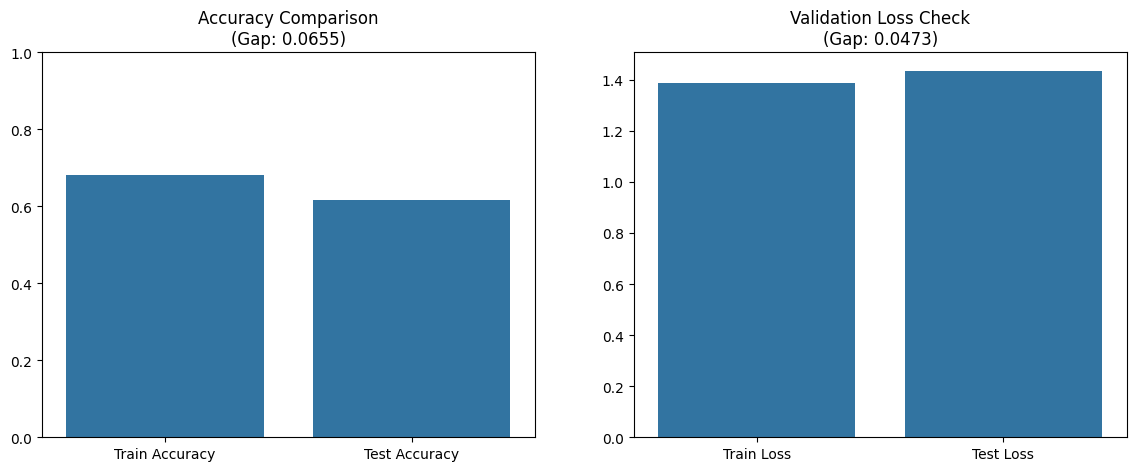


                  EMOTION CLASSIFICATION REPORT                  
              precision    recall  f1-score   support

       anger       0.55      0.57      0.56       647
     disgust       0.60      0.65      0.62       640
     sadness       0.68      0.64      0.66       649
       shame       0.58      0.47      0.52       643
        fear       0.67      0.72      0.69       646
         joy       0.63      0.75      0.69       655
       guilt       0.59      0.51      0.55       629

    accuracy                           0.62      4509
   macro avg       0.62      0.62      0.61      4509
weighted avg       0.62      0.62      0.61      4509



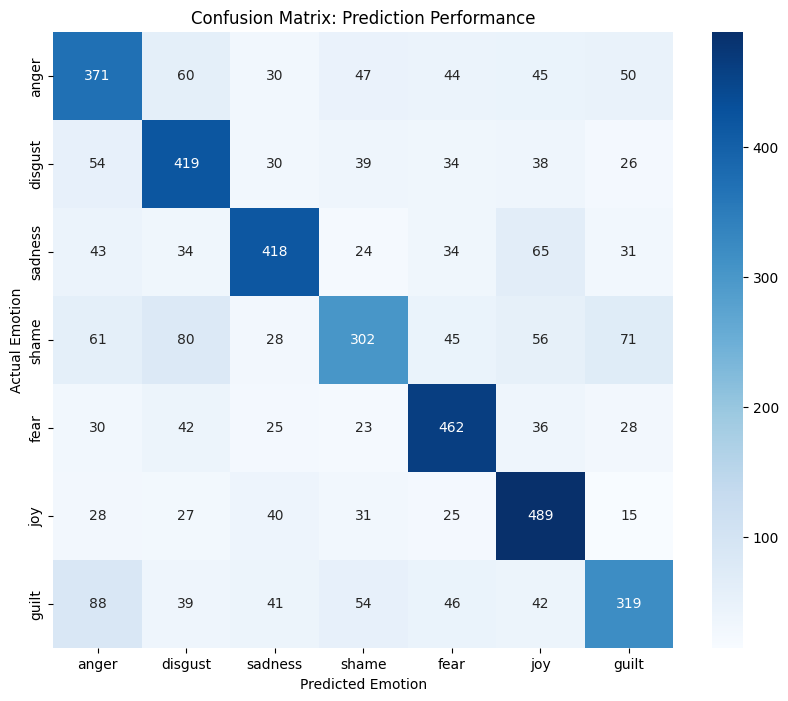

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, log_loss, confusion_matrix
)

# 1. Get emotion names in the exact order of your 0-6 labels
# This ensures target_names[0] is the name for label 0, target_names[1] for label 1, etc.
target_names = df.sort_values('labels')['emotion'].unique().tolist()

# 2. Initialize and Train Model
# Using C=0.5 for regularization as requested to prevent overfitting
model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 3. Predictions and Probabilities
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_proba = model.predict_proba(X_train)
y_test_proba = model.predict_proba(X_test)

# 4. Accuracy and Loss Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_loss = log_loss(y_train, y_train_proba)
test_loss = log_loss(y_test, y_test_proba)

# 5. --- VISUALIZATION: THE OVERFITTING PROOF ---
plt.figure(figsize=(14, 5))

# Plot Accuracy (Goal: Small gap between bars)
plt.subplot(1, 2, 1)
sns.barplot(x=['Train Accuracy', 'Test Accuracy'], y=[train_acc, test_acc])
plt.title(f'Accuracy Comparison\n(Gap: {abs(train_acc - test_acc):.4f})')
plt.ylim(0, 1)

# Plot Loss (Goal: Stable validation loss)
plt.subplot(1, 2, 2)
sns.barplot(x=['Train Loss', 'Test Loss'], y=[train_loss, test_loss])
plt.title(f'Validation Loss Check\n(Gap: {abs(train_loss - test_loss):.4f})')

plt.show()

# 6. --- CLASSIFICATION REPORT ---
# This shows Precision, Recall, and F1 for every emotion (0-6)
print("\n" + "="*65)
print(f"{'EMOTION CLASSIFICATION REPORT':^65}")
print("="*65)
print(classification_report(y_test, y_test_pred, target_names=target_names))

# 7. --- CONFUSION MATRIX ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Prediction Performance")
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

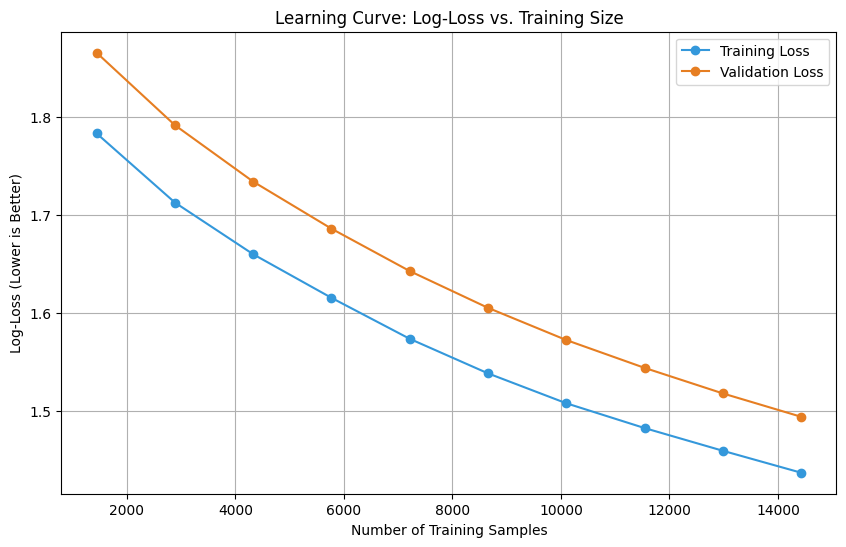

Final Loss Gap: 0.0569
Convergence detected: Your model is NOT overfitting.


In [ ]:
from sklearn.model_selection import learning_curve

# 1. Define the sizes of the training data to test (from 10% to 100%)
train_sizes = np.linspace(0.1, 1.0, 10)

# 2. Calculate Learning Curve Data (using negative log loss)
# We use 'neg_log_loss' because learning_curve tries to maximize scores
sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5,
    train_sizes=train_sizes,
    scoring='neg_log_loss',
    n_jobs=-1
)

# 3. Convert back to positive Log-Loss
train_loss_mean = -np.mean(train_scores, axis=1)
test_loss_mean = -np.mean(test_scores, axis=1)

# 4. Plotting the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(sizes, train_loss_mean, 'o-', color="#3498db", label="Training Loss")
plt.plot(sizes, test_loss_mean, 'o-', color="#e67e22", label="Validation Loss")



plt.title("Learning Curve: Log-Loss vs. Training Size")
plt.xlabel("Number of Training Samples")
plt.ylabel("Log-Loss (Lower is Better)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# 5. Final Confirmation
gap = test_loss_mean[-1] - train_loss_mean[-1]
print(f"Final Loss Gap: {gap:.4f}")
if gap < 0.1:
    print("Convergence detected: Your model is NOT overfitting.")
else:
    print("Gap detected: The model might be slightly overfitting.")

# ***For thesis***
You can say:

“Logistic Regression was evaluated using log-loss learning curves. The stable gap between training and validation loss indicates that the model generalizes well without severe overfitting

In [ ]:
# 1. Define your new test sentences
test_sentences = [
    "I am so happy that I passed my exam today!!!",
    "I feel very lonely and sad in this dark room.",
    "He shouted at me and I felt so much anger.",
    "I am terrified of what might happen next?",
    "I feel a bit ashamed of my behavior last night."
]

# 2. Function to predict emotion
def predict_emotion(texts):
    # Apply the cleaning function we created in Block 2
    cleaned_texts = [clean_text(t) for t in texts]

    # Transform using the EXISTING tfidf (do NOT use fit_transform)
    vectorized_texts = tfidf.transform(cleaned_texts)

    # Get numeric predictions
    predictions = model.predict(vectorized_texts)

    # Get probabilities to see how confident the model is
    probabilities = np.max(model.predict_proba(vectorized_texts), axis=1)

    # Map numeric labels back to emotion names using your sorted list
    results = []
    for pred, prob in zip(predictions, probabilities):
        emotion_name = target_names[pred]
        results.append((emotion_name, prob))
    return results

# 3. Run and Print Results
print(f"{'Original Sentence':<50} | {'Predicted Emotion':<15} | {'Confidence'}")
print("-" * 85)

results = predict_emotion(test_sentences)
for sentence, result in zip(test_sentences, results):
    emotion, confidence = result
    print(f"{sentence[:48]:<50} | {emotion:<15} | {confidence:.2%}")

Original Sentence                                  | Predicted Emotion | Confidence
-------------------------------------------------------------------------------------
I am so happy that I passed my exam today!!!       | joy             | 71.41%
I feel very lonely and sad in this dark room.      | sadness         | 41.40%
He shouted at me and I felt so much anger.         | anger           | 37.79%
I am terrified of what might happen next?          | fear            | 17.59%
I feel a bit ashamed of my behavior last night.    | shame           | 51.69%


In [ ]:
import os
import joblib

# 1. Define folder paths
models_folder = '/content/drive/MyDrive/Models'
results_folder = '/content/drive/MyDrive/Models_Results'


# 2. Save the LR Model and Vectorizer
joblib.dump(model, os.path.join(models_folder, 'LogisticRegression.pkl'))
joblib.dump(tfidf, os.path.join(models_folder, 'LR_TFIDF_Vectorizer_Final.pkl'))

# 3. Save the Classification Report as a Text File
report = classification_report(y_test, y_test_pred, target_names=target_names)
with open(os.path.join(results_folder, 'Logistic_Regression_Results.txt'), 'w') as f:
    f.write(report)

print(f"LR Model saved to: {models_folder}")
print(f"LR Report saved to: {results_folder}")

✅ LR Model saved to: /content/drive/MyDrive/Models
✅ LR Report saved to: /content/drive/MyDrive/Models_Results
